<a href="https://colab.research.google.com/github/LoneWolf2026/Neural-Network-for-Nuclear-Binding-Energy-Prediction-/blob/main/Semi_Empirical_Mass_Formula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import Atomic Mass Evaluation Dataset here
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

data_df_2020 = pd.read_csv('/content/drive/MyDrive/AME_Dataset_2020.csv',header =None)
data_df_2020 = data_df_2020.drop([0, 1]).reset_index(drop=True) #Drop first two rows (first two rows are individual proton and neutron)

data_df_2016 = pd.read_csv('/content/drive/MyDrive/AME_Dataset_2016.csv',header =None)
data_df_2016 = data_df_2016.drop([0, 1]).reset_index(drop=True) #Same as above

data_df_2016.name = "AME_2016"
data_df_2020.name = "AME_2020"


data_df_2016.iloc[:,7] = data_df_2016.iloc[:,7]/1000 #convert keV to MeV
data_df_2020.iloc[:,7] = data_df_2020.iloc[:,7]/1000

In [ ]:
data_df_2020.head()
data_df_2016.head()

,0,1,2,3,4,5,6,7,8,9,10
0,0,1,1,2,H,13135.72176,0.00011,1.112283,0.0,14101.77811,0.00012
1,1,2,1,3,H,14949.80993,0.00022,2.827265,0.0,16049.28199,0.00023
2,-1,1,2,3,He,14931.21793,0.00021,2.572680,0.0,16029.32265,0.00022
3,-3,0,3,3,Li,28667.00000,2000.00000,-2.267000,667.0,30775.00000,2147.00000
4,2,3,1,4,H,24621.12700,100.00000,1.720449,25.0,26431.86800,107.35400


In [ ]:
#Two papers I found have two different Semi Empirical Mass Formula (SEMF) coefficients (one based on AME2016 and the second based on AME2020 results). I decided to include both.

#Each set of coefficients will use the corresponding dataset from which they were derived


def SEMF_2016(A,Z,delta):

  #Coefficients and pairing term from:
  #Source: Benzaid D., et al. (2020)

  a_v = 14.6433 #MeV
  a_s = 14.0788
  a_c = 0.6442
  a_sym = 21.0680
  a_p = 11.5398

  binding_energy = a_v*A - a_s*(A**(2/3)) - a_c*(Z**2)/(A**(1/3)) - a_sym*(((A-2*Z)**2)/A) + delta*a_p*(1/(A**(1/2)))

  return binding_energy

def SEMF_2020(A,Z,delta):

  #Coefficients and pairing term from:
  #Gjorgievska S., et al. (2024)

  a_v = 15.582546 #MeV
  a_s = 17.377737
  a_c = 0.706489
  a_sym = 22.973123
  a_p = 13.013764

  binding_energy = a_v*A - a_s*(A**(2/3)) - a_c*(Z*(Z-1)/(A**(1/3))) - a_sym*(((A-2*Z)**2)/A) + delta*a_p*(1/(A**(1/2)))

  return binding_energy


def Binding_Energy_AME(data_df):
  N = data_df.iloc[:,1] #Neutrons
  Z = data_df.iloc[:,2] #Protons
  A = data_df.iloc[:,3] #Mass Number

  BE_per_Nucleon = []
  binding_energy = 0

  for i in range(len(N)):

    #delta is +- 1 or 0 depending on nucleon parity

    if N[i]%2 == 0 and Z[i]%2 == 0:
      delta = 1
    elif A[i]%2 == 1:
      delta = 0
    elif N[i]%2 == 1 and Z[i]%2 == 1:
      delta = -1

    if data_df.name == "AME_2016":
      binding_energy = SEMF_2016(A[i],Z[i],delta)

    elif data_df.name == "AME_2020":
      binding_energy = SEMF_2016(A[i],Z[i],delta)

    binding_energy_per_nucleon = round(binding_energy/A[i],4)
    BE_per_Nucleon.append(binding_energy_per_nucleon)

  return BE_per_Nucleon #return list of Binding Energies per Nucleon


In [ ]:
Prediction_Error_2016 = []
Prediction_Error_2020 = []
BE_per_A_Actual_2016 = data_df_2016.iloc[:,7]
BE_per_A_Actual_2020 = data_df_2020.iloc[:,7]

BEs_per_A_2016 = Binding_Energy_AME(data_df_2016)
BEs_per_A_2020 = Binding_Energy_AME(data_df_2020)

Nucleons2016 = list(data_df_2016.iloc[:,3]) #Convert data table into list to plot for matplotlib
Nucleons2020 = list(data_df_2020.iloc[:,3]) #Same as above


for a in range(len(BEs_per_A_2016)):
  error = abs((BEs_per_A_2016[a] - BE_per_A_Actual_2016[a])/BE_per_A_Actual_2016[a])*100 #Percent error in prediction by SEMF
  Prediction_Error_2016.append(error)

for a in range(len(BEs_per_A_2020)):
  error = abs((BEs_per_A_2020[a] - BE_per_A_Actual_2020[a])/BE_per_A_Actual_2020[a])*100  #Percent error in prediction by SEMF
  Prediction_Error_2020.append(error)


In [ ]:
print(len(Prediction_Error_2016))
print(len(Prediction_Error_2020))
print(len(BEs_per_A_2016))
print(len(BEs_per_A_2020))

3434
3556
3434
3556


In [12]:
for a in range(len(BEs_per_A_2016)):
  if BEs_per_A_2016[a] < 0:
    #Remove negative, predicted binding energies
    Nucleons2016.remove(Nucleons2016[a]) #Remove nucleons corresponding to negative predicted energies
    Prediction_Error_2016.remove(Prediction_Error_2016[a]) #Remove accuracies corresponding to negative predicted energies

BEs_per_A_2016 = [k for k in BEs_per_A_2016 if k > 0] #Keep only positive predicted Binding Energies


for c in range(len(Prediction_Error_2016)):
  if Prediction_Error_2016[c] > 2: #Remove Nucleons and Binding Energies corresponding to outlier errors
    BEs_per_A_2016.remove(BEs_per_A_2016[c])
    Nucleons2016.remove(Nucleons2016[c])

Prediction_Error_2016 = [j for j in Prediction_Error_2016 if j < 2] #Keep only reasonably small prediction errors


for b in range(len(BEs_per_A_2020)):
  if BEs_per_A_2020[b] < 0:
    Nucleons2020.remove(Nucleons2020[b]) #Same purpose as .remove() for BEs_per_A_2016
    Prediction_Error_2020.remove(Prediction_Error_2020[b])

BEs_per_A_2020 = [k for k in BEs_per_A_2020 if k > 0] #Keep only positive predicted Binding Energies


for c in range(len(Prediction_Error_2020)):
  if Prediction_Error_2020[c] > 2: #Remove Nucleons and Binding Energies corresponding to outlier errors
    BEs_per_A_2020.remove(BEs_per_A_2020[c])
    Nucleons2020.remove(Nucleons2020[c])

Prediction_Error_2020 = [j for j in Prediction_Error_2020 if j < 2] #Keep only reasonably small prediction errors


#Including BEs_per_A_2020 in the for loops would've led to an IndexError, as the length of the list which the for loop iterates over is changing as well. Same goes for Prediction_Error_2016 and 2020

In [ ]:
print(len(Prediction_Error_2016))
print(len(Prediction_Error_2020))
print(len(BEs_per_A_2016))
print(len(BEs_per_A_2020))

3402
3522
3402
3522


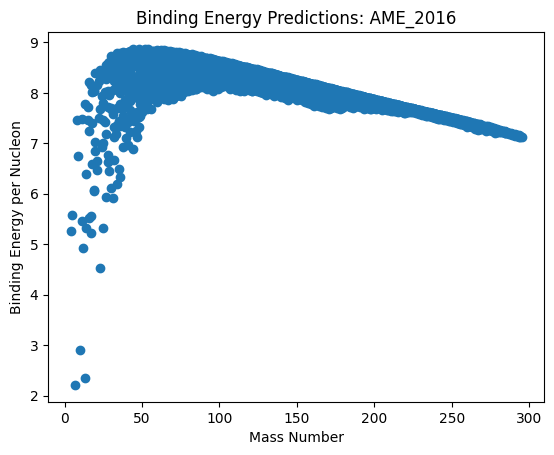

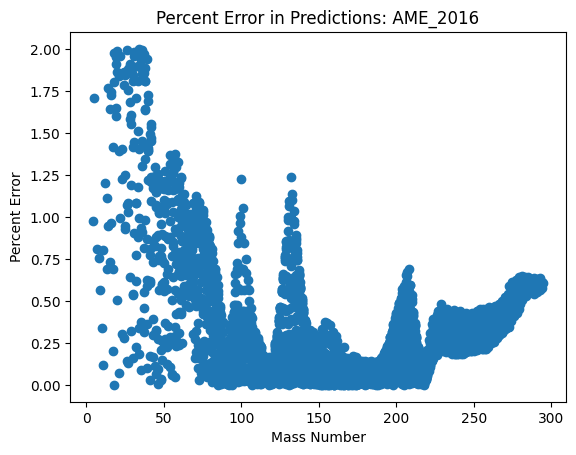

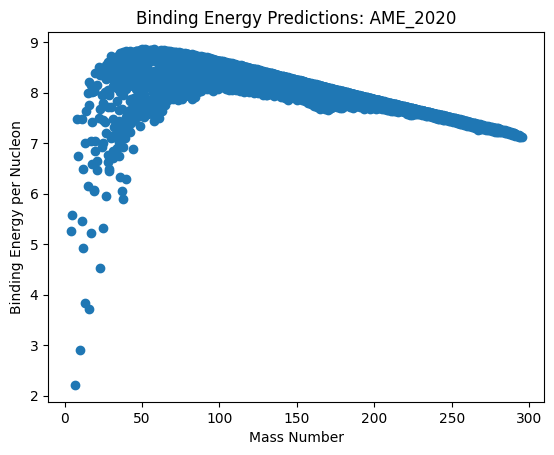

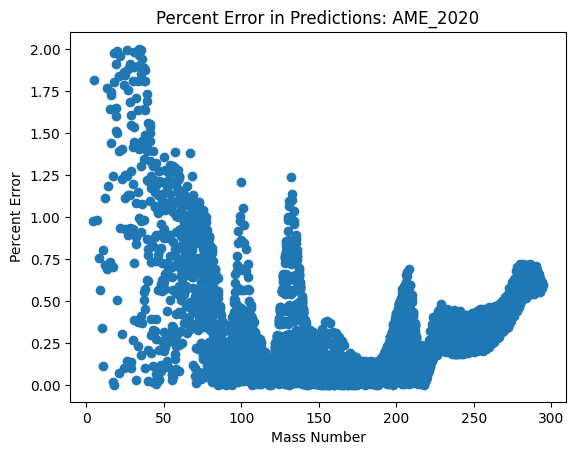

In [13]:
import matplotlib.pyplot as plt

#x axis is Mass Number(s)
#y axis is Binding Energy in MeV per Nucleon

x1 = Nucleons2016
y1 = BEs_per_A_2016

plt.figure(1)
plt.scatter(x1,y1)
plt.xlabel('Mass Number')
plt.ylabel('Binding Energy per Nucleon')
plt.title('Binding Energy Predictions: AME_2016')
plt.show()


x2 = Nucleons2016
y2 = Prediction_Error_2016

plt.figure(2)
plt.scatter(x2,y2)
plt.xlabel('Mass Number')
plt.ylabel('Percent Error')
plt.title('Percent Error in Predictions: AME_2016')
plt.show()


#x axis is Mass Number(s)
#y axis is Binding Energy in MeV per Nucleon

x3 = Nucleons2020
y3 = BEs_per_A_2020

plt.figure(3)
plt.scatter(x3,y3)
plt.xlabel('Mass Number')
plt.ylabel('Binding Energy per Nucleon')
plt.title('Binding Energy Predictions: AME_2020')
plt.show()


x4 = Nucleons2020
y4 = Prediction_Error_2020

plt.figure(4)
plt.scatter(x4,y4)
plt.xlabel('Mass Number')
plt.ylabel('Percent Error')
plt.title('Percent Error in Predictions: AME_2020')
plt.show()

